# Zone-Based Vegetation Recommendation

Notebook ini merefactor pipeline rekomendasi vegetasi/tanaman menjadi **zone-based recommendation system**. Unit prediksi utama bukan lagi satu titik sensor, tetapi satu zona yang dibentuk dari beberapa titik sampling.

Notebook ini kompatibel dengan Google Colab selama seluruh folder project tersedia, bukan file notebook saja.


## Colab Setup

Jika dijalankan di Google Colab:

1. Upload atau mount seluruh folder project.
2. Simpan project di `/content/DATAHACTHON` atau di Google Drive.
3. Jika project ada di Drive, aktifkan `MOUNT_GOOGLE_DRIVE` lalu isi `COLAB_PROJECT_ROOT`.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
MOUNT_GOOGLE_DRIVE = False
COLAB_PROJECT_ROOT = None
# Contoh:
# MOUNT_GOOGLE_DRIVE = True
# COLAB_PROJECT_ROOT = "/content/drive/MyDrive/DATAHACTHON"

if IN_COLAB and MOUNT_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

if IN_COLAB:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pandas",
            "numpy",
            "scikit-learn",
            "matplotlib",
            "seaborn",
            "joblib",
            "nbformat",
        ]
    )


def _is_project_root(path: Path) -> bool:
    return (path / "scripts").exists() and (path / "datasets").exists()


def resolve_project_root(explicit_root: str | None = None) -> Path:
    if explicit_root:
        candidate = Path(explicit_root).expanduser().resolve()
        if _is_project_root(candidate):
            return candidate
        raise FileNotFoundError(
            f"COLAB_PROJECT_ROOT tidak valid: {candidate}. "
            "Folder harus mengandung `scripts/` dan `datasets/`."
        )

    cwd = Path.cwd().resolve()
    direct_candidates = [
        cwd,
        *cwd.parents,
        Path("/content/DATAHACTHON"),
        Path("/content/drive/MyDrive/DATAHACTHON"),
        Path("/content/drive/MyDrive/Colab Notebooks/DATAHACTHON"),
    ]

    seen = set()
    for candidate in direct_candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists() and _is_project_root(candidate):
            return candidate

    search_bases = [Path("/content"), Path("/content/drive/MyDrive")]
    search_patterns = [
        "*/scripts/common.py",
        "*/*/scripts/common.py",
        "*/*/*/scripts/common.py",
    ]
    for base in search_bases:
        if not base.exists():
            continue
        for pattern in search_patterns:
            for match in base.glob(pattern):
                candidate = match.parents[1]
                if _is_project_root(candidate):
                    return candidate

    raise FileNotFoundError(
        "Project root tidak ditemukan. "
        "Pastikan seluruh folder project tersedia, lalu set COLAB_PROJECT_ROOT bila perlu."
    )


PROJECT_ROOT = resolve_project_root(COLAB_PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("IN_COLAB =", IN_COLAB)
print("PROJECT_ROOT =", PROJECT_ROOT)


IN_COLAB = False
PROJECT_ROOT = /home/stardust/Documents/Kuliah/DATAHACTHON


## 1. Problem Framing

**Objective**

Membangun sistem rekomendasi vegetasi/tanaman berbasis **zona**, bukan satu titik sensor.

**Why zone-based**

Di lapangan, nilai N, P, K, pH, dan parameter tanah lain dapat berubah cukup tajam walau jarak antar titik dekat. Karena itu, beberapa titik harus digabung menjadi representasi zona, dan variasi internal zona perlu dipertahankan melalui fitur agregasi seperti mean, std, min, max, range, dan sample count.


In [2]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

from scripts.build_zone_dataset import prepare_zone_datasets
from scripts.train_zone_model import run_zone_pipeline
from scripts.common import (
    BEST_ZONE_MODEL_PATH,
    ZONE_DATASET_EXTENDED_PATH,
    ZONE_DATASET_MINIMAL_PATH,
    ZONE_FEATURE_IMPORTANCE_PATH,
    ZONE_METADATA_PATH,
    ZONE_MODEL_METRICS_PATH,
    ZONE_PREDICTION_SAMPLES_PATH,
    ZONE_TARGET_COLUMN,
)

RANDOM_STATE = 42


## 2. Build Zone Dataset

Cell ini menjalankan pipeline pembentukan dataset zona dari data titik mentah. Jika raw data tidak memiliki `zone_id`, pipeline akan membentuk pseudo-zone yang terdokumentasi di artifact strategy.


In [3]:
zone_result = run_zone_pipeline(save_artifacts=True, random_state=RANDOM_STATE)
bundle = zone_result["bundle"]
metrics = zone_result["metrics_payload"]

point_df = bundle["point_df"]
filtered_point_df = bundle["filtered_point_df"]
zone_minimal_df = bundle["zone_minimal_df"]
zone_extended_df = bundle["zone_extended_df"]
zone_metadata = json.loads(ZONE_METADATA_PATH.read_text(encoding="utf-8"))

print("Point data shape after cleaning:", point_df.shape)
print("Filtered point data retained for zone modeling:", filtered_point_df.shape)
print("Zone minimal shape:", zone_minimal_df.shape)
print("Zone extended shape:", zone_extended_df.shape)


Point data shape after cleaning: (3841, 40)
Filtered point data retained for zone modeling: (902, 40)
Zone minimal shape: (33, 25)
Zone extended shape: (33, 149)


In [4]:
audit_summary = pd.DataFrame(
    [
        {"decision": "raw_data_structure", "value": "point_based"},
        {"decision": "zone_available_in_raw_data", "value": zone_metadata["zone_available_in_raw_data"]},
        {"decision": "zone_construction_required", "value": zone_metadata["zone_construction_required"]},
        {"decision": "zone_strategy_type", "value": zone_metadata["zone_strategy_type"]},
        {"decision": "target_column", "value": zone_metadata["target_column"]},
        {"decision": "n_raw_points", "value": zone_metadata["number_of_raw_points_after_basic_cleaning"]},
        {"decision": "n_final_zones", "value": zone_metadata["number_of_final_zones"]},
        {"decision": "avg_points_per_zone", "value": zone_metadata["average_points_per_zone"]},
    ]
)
display(audit_summary)

print("Zone builder params:")
display(pd.DataFrame([zone_metadata["zone_builder_params"]]))


,decision,value
0,raw_data_structure,point_based
1,zone_available_in_raw_data,False
2,zone_construction_required,True
3,zone_strategy_type,fallback_pseudo_zone_from_shared_weather_conte...
4,target_column,zone_target
5,n_raw_points,3841
6,n_final_zones,33
7,avg_points_per_zone,31.090909


Zone builder params:


,target_zone_size,min_samples_per_zone,min_zone_label_dominance_ratio,min_zones_per_class,cluster_features
0,25,8,0.6,3,"[ph, potassium, phosphorus, nitrogen, zinc, su..."


## 3. Dataset Audit And Zone EDA

Fokus audit:

- Apakah data awal titik atau zona
- Berapa banyak zona yang benar-benar layak dipakai
- Seberapa besar variasi internal zona yang berhasil dipertahankan


Class distribution at zone level:


,zone_target,zone_count
0,Maize,13
1,Teff,12
2,Wheat,4
3,Barley,4


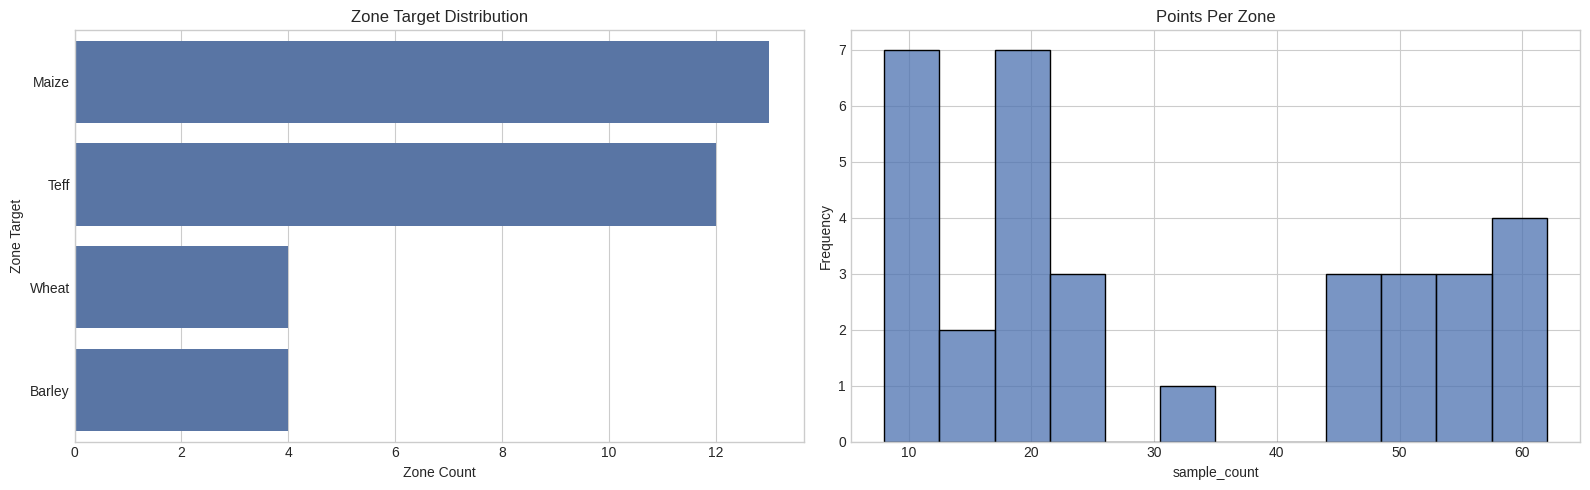

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

target_counts = zone_extended_df[ZONE_TARGET_COLUMN].value_counts()
sns.barplot(x=target_counts.values, y=target_counts.index, ax=axes[0])
axes[0].set_title("Zone Target Distribution")
axes[0].set_xlabel("Zone Count")
axes[0].set_ylabel("Zone Target")

sns.histplot(zone_extended_df["sample_count"], bins=12, ax=axes[1])
axes[1].set_title("Points Per Zone")
axes[1].set_xlabel("sample_count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
print("Class distribution at zone level:")
display(target_counts.rename_axis("zone_target").reset_index(name="zone_count"))


,zone_id,zone_target,sample_count,ph_std,nitrogen_std,phosphorus_std,potassium_std,temperature_mean_std,rainfall_mean_std
0,zone_01_02,Wheat,20,0.306931,0.035838,9.290769,99.199484,0.0,0.0
1,zone_01_03,Barley,58,0.204262,0.025635,15.138170,93.837547,0.0,0.0
2,zone_01_08,Barley,21,0.261698,0.041740,8.193431,111.921925,0.0,0.0
3,zone_02_05,Teff,59,0.278459,0.026202,2.527142,98.488825,0.0,0.0
4,zone_06_11,Teff,24,0.475840,0.034447,44.467038,137.121656,0.0,0.0
5,zone_06_12,Teff,50,0.350757,0.030610,4.070782,71.805033,0.0,0.0
6,zone_07_00,Wheat,44,0.511325,0.000000,14.594309,98.557556,0.0,0.0
7,zone_08_00,Barley,17,0.387145,0.000000,19.288793,170.692667,0.0,0.0
8,zone_09_01,Teff,57,0.344603,0.025867,3.952597,84.525423,0.0,0.0
9,zone_09_04,Teff,49,0.533298,0.028789,9.533950,111.772669,0.0,0.0


Key insight: representasi zona tidak hanya berisi mean. Kolom std/min/max/range/cv tersedia pada extended dataset untuk mempertahankan variasi internal.


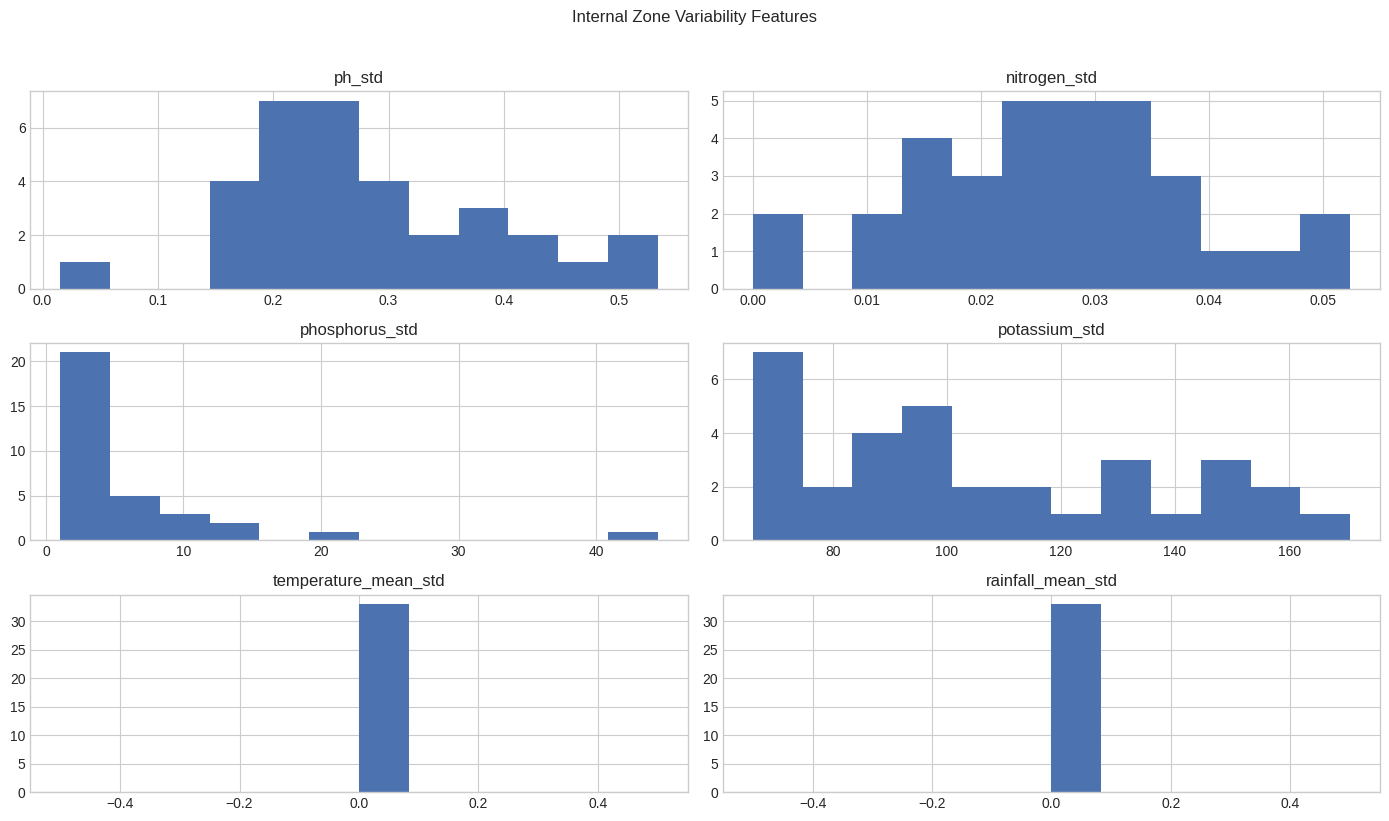

In [6]:
variability_columns = [
    "ph_std",
    "nitrogen_std",
    "phosphorus_std",
    "potassium_std",
    "temperature_mean_std",
    "rainfall_mean_std",
]
available_variability_columns = [column for column in variability_columns if column in zone_extended_df.columns]

if available_variability_columns:
    zone_extended_df[available_variability_columns].hist(figsize=(14, 8), bins=12)
    plt.suptitle("Internal Zone Variability Features", y=1.02)
    plt.tight_layout()

variability_snapshot = zone_extended_df[
    ["zone_id", ZONE_TARGET_COLUMN, "sample_count", *available_variability_columns]
].head(10)
display(variability_snapshot)

print(
    "Key insight: representasi zona tidak hanya berisi mean. "
    "Kolom std/min/max/range/cv tersedia pada extended dataset untuk mempertahankan variasi internal."
)


## 4. Modeling Strategy

Dua eksperimen utama dibandingkan:

1. **Point-to-zone baseline**: model dilatih pada titik, lalu prediksi titik diagregasi ke level zona.
2. **Zone model**: model dilatih langsung pada fitur agregasi level zona.

Untuk zone model, dibandingkan dua representasi:

- `mean-only`
- `mean + variability`


In [7]:
comparison_rows = [
    {
        "scenario": "point_to_zone_baseline",
        "model": metrics["point_to_zone_baseline"]["best_model_name"],
        "selection_strategy": "validation_holdout_group_aligned",
        "validation_f1_macro": metrics["point_to_zone_baseline"]["validation_metrics"]["validation_f1_macro"],
        "test_f1_macro": metrics["point_to_zone_baseline"]["test_metrics"]["f1_macro"],
        "test_accuracy": metrics["point_to_zone_baseline"]["test_metrics"]["accuracy"],
    },
    {
        "scenario": "zone_mean_only",
        "model": metrics["zone_mean_only"]["best_model_name"],
        "selection_strategy": metrics["zone_mean_only"]["selection_strategy"],
        "validation_f1_macro": metrics["zone_mean_only"]["validation_metrics"]["f1_macro"],
        "test_f1_macro": metrics["zone_mean_only"]["test_metrics"]["f1_macro"],
        "test_accuracy": metrics["zone_mean_only"]["test_metrics"]["accuracy"],
    },
    {
        "scenario": "zone_mean_plus_variability",
        "model": metrics["zone_mean_plus_variability"]["best_model_name"],
        "selection_strategy": metrics["zone_mean_plus_variability"]["selection_strategy"],
        "validation_f1_macro": metrics["zone_mean_plus_variability"]["validation_metrics"]["f1_macro"],
        "test_f1_macro": metrics["zone_mean_plus_variability"]["test_metrics"]["f1_macro"],
        "test_accuracy": metrics["zone_mean_plus_variability"]["test_metrics"]["accuracy"],
    },
]

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["test_f1_macro", "test_accuracy"], ascending=False
)
display(comparison_df)


,scenario,model,selection_strategy,validation_f1_macro,test_f1_macro,test_accuracy
0,point_to_zone_baseline,logistic_regression,validation_holdout_group_aligned,0.425000,0.666667,0.857143
1,zone_mean_only,random_forest,validation_holdout_fallback,0.366667,0.464286,0.714286
2,zone_mean_plus_variability,logistic_regression,validation_holdout_fallback,0.342857,0.380952,0.571429


In [8]:
print("Selected zone scenario:", metrics["selected_zone_scenario"])
print("Selected zone model:", metrics["selected_zone_model_name"])
print("Selected zone params:", metrics["selected_zone_model_params"])
print("Variability helps on validation:", metrics["variability_features_help_validation"])
print("Variability helps on test:", metrics["variability_features_help_test"])
print("Zone model beats point baseline on test:", metrics["zone_model_beats_point_baseline"])

print(
    "\nInterpretation:\n"
    "- Secara implementasi lapangan, framing zona tetap lebih tepat daripada satu titik.\n"
    "- Namun pada dataset ini, pseudo-zone yang terbentuk masih kecil dan tidak punya koordinat eksplisit, "
    "sehingga model zona belum mengungguli baseline point-to-zone pada split saat ini."
)


Selected zone scenario: zone_mean_only
Selected zone model: random_forest
Selected zone params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 120}
Variability helps on validation: False
Variability helps on test: False
Zone model beats point baseline on test: False

Interpretation:
- Secara implementasi lapangan, framing zona tetap lebih tepat daripada satu titik.
- Namun pada dataset ini, pseudo-zone yang terbentuk masih kecil dan tidak punya koordinat eksplisit, sehingga model zona belum mengungguli baseline point-to-zone pada split saat ini.


## 5. Feature Importance

Importance dihitung pada **skenario zona terpilih** menggunakan permutation importance pada test split.


,scenario_name,feature,importance_mean,importance_std
0,zone_mean_only,soil_color_mode,0.078373,0.055750
1,zone_mean_only,nitrogen_mean,0.065079,0.046018
2,zone_mean_only,temperature_mean_mean,0.014286,0.000000
3,zone_mean_only,surface_pressure_mean,0.014286,0.000000
4,zone_mean_only,specific_humidity_mean_mean,0.004762,0.006734
5,zone_mean_only,sample_count,0.000000,0.000000
6,zone_mean_only,context_sample_count,0.000000,0.000000
7,zone_mean_only,context_cluster_count,0.000000,0.000000
8,zone_mean_only,soil_color_dominant_ratio,0.000000,0.000000
9,zone_mean_only,ph_mean,0.000000,0.000000


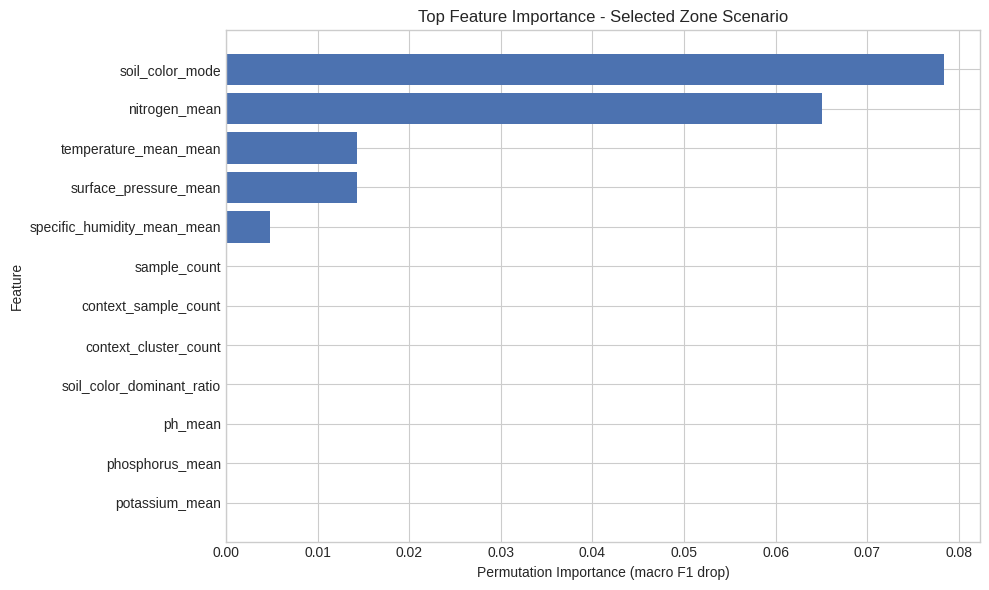

In [9]:
feature_importance_df = pd.read_csv(ZONE_FEATURE_IMPORTANCE_PATH).sort_values(
    "importance_mean", ascending=False
)
display(feature_importance_df.head(15))

plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(12).iloc[::-1]
plt.barh(top_features["feature"], top_features["importance_mean"])
plt.title("Top Feature Importance - Selected Zone Scenario")
plt.xlabel("Permutation Importance (macro F1 drop)")
plt.ylabel("Feature")
plt.tight_layout()


## 6. Error Analysis

Error analysis penting karena jumlah zona final masih kecil dan beberapa kelas minor sulit dipelajari model dengan stabil.


In [10]:
prediction_samples = pd.read_csv(ZONE_PREDICTION_SAMPLES_PATH)
display(prediction_samples)

misclassified = prediction_samples.loc[prediction_samples["is_correct"] == 0].copy()
print("Misclassified zones:", misclassified.shape[0])
display(misclassified)


,zone_id,base_context_id,sample_count,actual_target,predicted_target,is_correct,top_3_predictions
0,zone_08_00,8,17,Barley,Wheat,0,Wheat:0.4667 | Barley:0.3083 | Teff:0.1167
1,zone_09_01,9,57,Teff,Teff,1,Teff:0.4833 | Wheat:0.2083 | Maize:0.1833
2,zone_09_04,9,49,Teff,Teff,1,Teff:0.5417 | Wheat:0.2333 | Maize:0.1500
3,zone_14_04,14,9,Teff,Teff,1,Teff:0.7583 | Wheat:0.1417 | Maize:0.0667
4,zone_14_15,14,9,Wheat,Teff,0,Teff:0.3083 | Barley:0.2583 | Maize:0.2500
5,zone_16_01,16,45,Maize,Maize,1,Maize:0.6667 | Wheat:0.1583 | Teff:0.1167
6,zone_16_08,16,20,Maize,Maize,1,Maize:0.6667 | Wheat:0.2000 | Teff:0.0833


Misclassified zones: 2


,zone_id,base_context_id,sample_count,actual_target,predicted_target,is_correct,top_3_predictions
0,zone_08_00,8,17,Barley,Wheat,0,Wheat:0.4667 | Barley:0.3083 | Teff:0.1167
4,zone_14_15,14,9,Wheat,Teff,0,Teff:0.3083 | Barley:0.2583 | Maize:0.2500


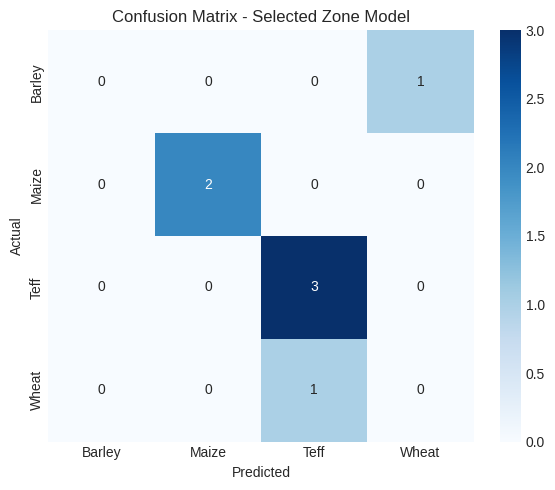

In [11]:
confusion_labels = metrics["selected_zone_confusion_matrix_labels"]
confusion_matrix_array = np.array(metrics["selected_zone_confusion_matrix"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix_array,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=confusion_labels,
    yticklabels=confusion_labels,
)
plt.title("Confusion Matrix - Selected Zone Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()


## 7. Simple Inference Example

Karena model terbaik tersimpan sebagai full scikit-learn pipeline, inferensi dapat dilakukan langsung dari dictionary fitur zona.


In [12]:
best_zone_model = joblib.load(BEST_ZONE_MODEL_PATH)
selected_scenario = metrics["selected_zone_scenario"]
selected_feature_columns = metrics[selected_scenario]["feature_columns"]

if selected_scenario == "zone_mean_only":
    inference_source = zone_minimal_df.copy()
else:
    inference_source = zone_extended_df.copy()

example_zone = inference_source.iloc[[0]].copy()
example_payload = example_zone[selected_feature_columns].to_dict(orient="records")[0]
example_prediction = best_zone_model.predict(example_zone[selected_feature_columns])[0]

print("Example payload:")
print(example_payload)
print("\nPredicted zone recommendation:", example_prediction)

if hasattr(best_zone_model, "predict_proba"):
    probabilities = best_zone_model.predict_proba(example_zone[selected_feature_columns])[0]
    top_idx = np.argsort(probabilities)[::-1][:3]
    top_predictions = [
        (best_zone_model.classes_[index], float(probabilities[index]))
        for index in top_idx
    ]
    print("Top-3 predictions:", top_predictions)


Example payload:
{'sample_count': 20, 'context_sample_count': 236, 'context_cluster_count': 9, 'soil_color_mode': 'black', 'soil_color_dominant_ratio': 0.7333333333333333, 'ph_mean': 6.762666666666666, 'nitrogen_mean': 0.19176666666666667, 'phosphorus_mean': 8.579, 'potassium_mean': 385.5928, 'zinc_mean': 1.5076666666666665, 'sulfur_mean': 8.99, 'soil_moisture_surface_mean': 0.65, 'wind_speed_10m_mean': 75.69, 'specific_humidity_mean_mean': 8.59500000075, 'temperature_mean_mean': 13.937083334125001, 'temperature_seasonal_range_mean': 23.563333337, 'rainfall_mean_mean': 3.2883333332499998, 'rainfall_total_proxy_mean': 13.153333332999999, 'cloud_amount_mean': 0.46, 'surface_pressure_mean': 74.17}

Predicted zone recommendation: Wheat
Top-3 predictions: [('Wheat', 0.7166666666666667), ('Barley', 0.15), ('Teff', 0.1)]


## 8. Final Takeaways

- Dataset mentah saat ini **berbasis titik**, bukan zona.
- Zona dibentuk melalui fallback `shared weather context + soil clustering`, karena tidak ada `zone_id`, `field_id`, atau koordinat.
- Extended zone dataset mempertahankan variasi internal lewat `std`, `min`, `max`, `range`, `cv`, dan `sample_count`.
- Pada split saat ini, model zona terpilih adalah `zone_mean_only`, sementara fitur variasi belum membantu performa.
- Secara konseptual, sistem zona tetap lebih tepat untuk deployment lapangan. Namun secara empiris, kualitas dataset zona saat ini masih dibatasi oleh tidak adanya informasi geospasial eksplisit.
